# Retail Sales Data Analysis

## Objective
The objective of this project is to analyze retail sales data and identify trends, customer behavior, product performance, and important business insights.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(r"D:\internship\retail_sales_dataset.csv")

In [2]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [3]:
df.shape

(1000, 9)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Product Category  1000 non-null   str  
 6   Quantity          1000 non-null   int64
 7   Price per Unit    1000 non-null   int64
 8   Total Amount      1000 non-null   int64
dtypes: int64(5), str(4)
memory usage: 100.2 KB


In [5]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [6]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [7]:
df .duplicated().sum()

np.int64(0)

In [8]:
df['Product Category'].value_counts()

Product Category
Clothing       351
Electronics    342
Beauty         307
Name: count, dtype: int64

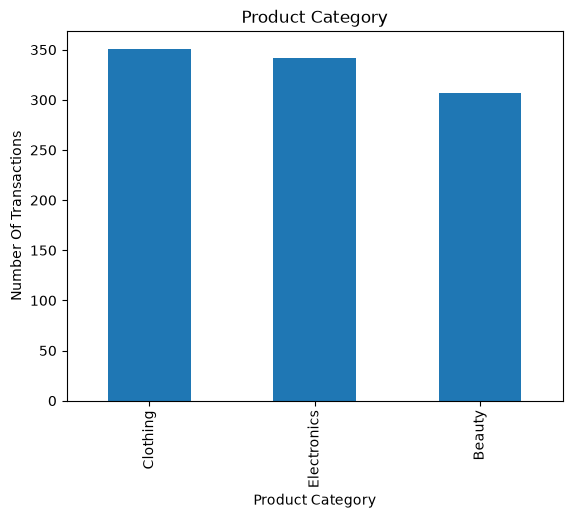

In [9]:
import matplotlib.pyplot as plt

df['Product Category'].value_counts().plot(kind='bar')

plt.title('Product Category')
plt.ylabel('Number Of Transactions')

plt.show()

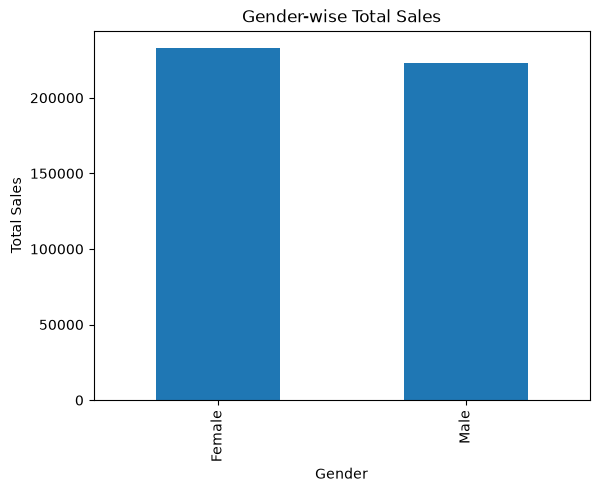

In [10]:
df.groupby('Gender')['Total Amount'].sum().plot(kind='bar')

plt.title('Gender-wise Total Sales')
plt.xlabel('Gender')
plt.ylabel('Total Sales')

plt.show()

In [11]:
df.groupby('Product Category')['Total Amount'].sum()

Product Category
Beauty         143515
Clothing       155580
Electronics    156905
Name: Total Amount, dtype: int64

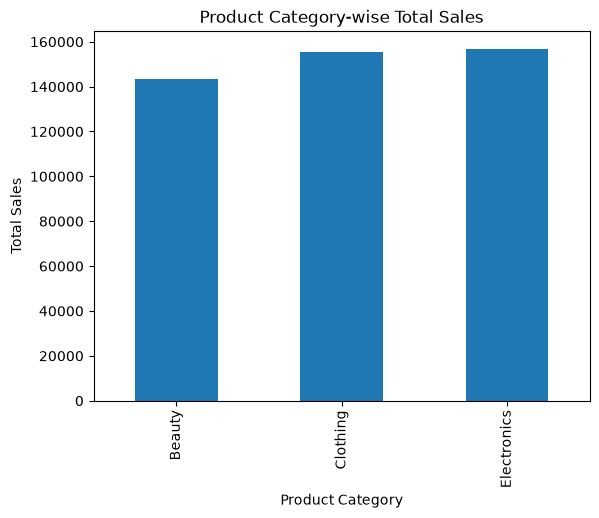

In [12]:
df.groupby('Product Category')['Total Amount'].sum().plot(kind='bar')

plt.title('Product Category-wise Total Sales')
plt.xlabel('Product Category')
plt.ylabel('Total Sales')

plt.show()

In [13]:
df['Age Group'] = pd.cut(
    df['Age'],
    bins=[0, 25, 35, 50, 65],
    labels=['18-25', '26-35', '36-50', '51-65']
)

In [14]:
df['Age Group'].value_counts().sort_index()

Age Group
18-25    169
26-35    205
36-50    313
51-65    313
Name: count, dtype: int64

In [15]:
df.groupby('Age Group', observed=True)['Total Amount'].sum()

Age Group
18-25     84550
26-35     98480
36-50    139660
51-65    133310
Name: Total Amount, dtype: int64

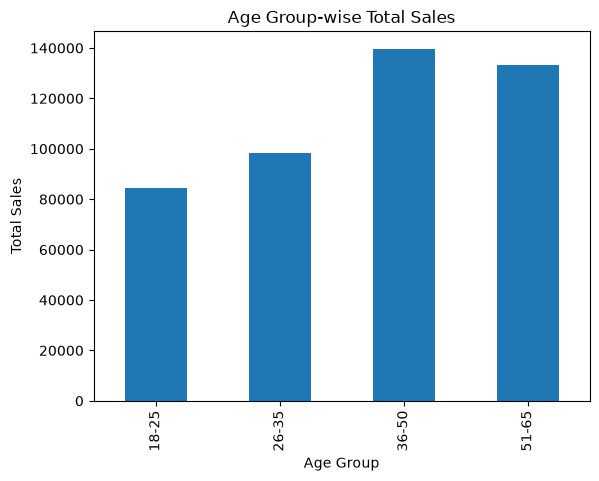

In [16]:
df.groupby('Age Group', observed=True)['Total Amount'].sum().plot(kind='bar')

plt.title('Age Group-wise Total Sales')
plt.xlabel('Age Group')
plt.ylabel('Total Sales')

plt.show()

In [17]:
df['Date'] = pd.to_datetime(df['Date'])

In [18]:
df['Month'] = df['Date'].dt.month_name()

In [19]:
df.groupby('Month')['Total Amount'].sum()

Month
April        33870
August       36960
December     44690
February     44060
January      36980
July         35465
June         36715
March        28990
May          53150
November     34920
October      46580
September    23620
Name: Total Amount, dtype: int64

In [20]:
monthly_sales = df.groupby(df['Date'].dt.month)['Total Amount'].sum()

monthly_sales.index = monthly_sales.index.map({
    1: 'January', 2: 'February', 3: 'March', 4: 'April',
    5: 'May', 6: 'June', 7: 'July', 8: 'August',
    9: 'September', 10: 'October', 11: 'November', 12: 'December'
})

monthly_sales

Date
January      36980
February     44060
March        28990
April        33870
May          53150
June         36715
July         35465
August       36960
September    23620
October      46580
November     34920
December     44690
Name: Total Amount, dtype: int64

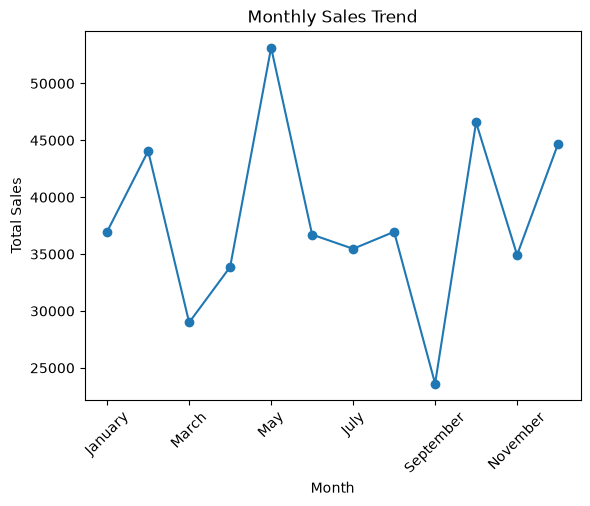

In [21]:
monthly_sales.plot(kind='line', marker='o')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')

plt.xticks(rotation=45)
plt.show()

In [22]:
df[['Age', 'Quantity', 'Price per Unit', 'Total Amount']].corr()

,Age,Quantity,Price per Unit,Total Amount
Age,1.000000,-0.023737,-0.038423,-0.060568
Quantity,-0.023737,1.000000,0.017501,0.373707
Price per Unit,-0.038423,0.017501,1.000000,0.851925
Total Amount,-0.060568,0.373707,0.851925,1.000000


In [23]:
import seaborn as sns

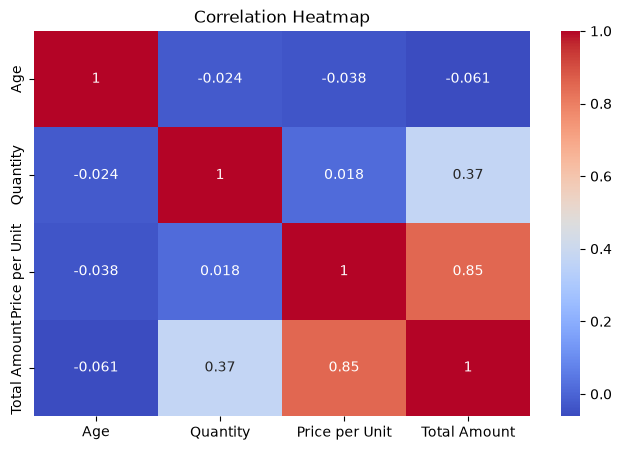

In [24]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    df[['Age', 'Quantity', 'Price per Unit', 'Total Amount']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.show()

In [25]:
print("""
BUSINESS INSIGHTS:

1. Electronics category generated the highest total sales.
2. Female customers generated slightly higher sales than male customers.
3. The 36-50 age group generated the highest total sales.
4. May recorded the highest monthly sales.
5. September recorded the lowest monthly sales.
6. Price per Unit has a strong positive correlation with Total Amount.
7. The dataset contains no missing values or duplicate records.
""")


BUSINESS INSIGHTS:

1. Electronics category generated the highest total sales.
2. Female customers generated slightly higher sales than male customers.
3. The 36-50 age group generated the highest total sales.
4. May recorded the highest monthly sales.
5. September recorded the lowest monthly sales.
6. Price per Unit has a strong positive correlation with Total Amount.
7. The dataset contains no missing values or duplicate records.



## Conclusion

The analysis shows that Electronics generated the highest sales, Female customers contributed slightly more to total sales, and the 36–50 age group was the highest spending customer segment. May recorded the highest monthly sales, while September recorded the lowest. Price per Unit showed a strong positive relationship with Total Amount.